# Principal Component Analysis with Cancer Data

In [40]:
#Import all the necessary modules
#Import all the necessary modules
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


from sklearn.decomposition import PCA
from scipy.stats import zscore

# Q1. Load the Data file into Python DataFrame and view top 10 rows

In [42]:
  # Id columns is to identify rows hence can be skipped in analysis
  # All columns have numerical values
  # Class would be the target variable. Should be removed when PCA is done

In [43]:
cancer_df = pd.read_csv("cancer.csv")

In [44]:
#Get Top 10 Rows
cancer_df.head(10)

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
5,1017122,8,10,10,8,7,10,9,7,1,4
6,1018099,1,1,1,1,2,10,3,1,1,2
7,1018561,2,1,2,1,2,1,3,1,1,2
8,1033078,2,1,1,1,2,1,1,1,5,2
9,1033078,4,2,1,1,2,1,2,1,1,2


# Q2 Print the datatypes of each column and the shape of the dataset. Perform descriptive analysis 

In [45]:
cancer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
ID                             699 non-null int64
ClumpThickness                 699 non-null int64
Cell Size                      699 non-null int64
Cell Shape                     699 non-null int64
Marginal Adhesion              699 non-null int64
Single Epithelial Cell Size    699 non-null int64
Bare Nuclei                    699 non-null object
Normal Nucleoli                699 non-null int64
Bland Chromatin                699 non-null int64
Mitoses                        699 non-null int64
Class                          699 non-null int64
dtypes: int64(10), object(1)
memory usage: 60.1+ KB


In [46]:
cancer_df.shape

(699, 11)

In [47]:
cancer_df.describe()

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Normal Nucleoli,Bland Chromatin,Mitoses,Class
count,6.990000e+02,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000
mean,1.071704e+06,4.417740,3.134478,3.207439,2.806867,3.216023,3.437768,2.866953,1.589413,2.689557
std,6.170957e+05,2.815741,3.051459,2.971913,2.855379,2.214300,2.438364,3.053634,1.715078,0.951273
min,6.163400e+04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,8.706885e+05,2.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,2.000000
50%,1.171710e+06,4.000000,1.000000,1.000000,1.000000,2.000000,3.000000,1.000000,1.000000,2.000000
75%,1.238298e+06,6.000000,5.000000,5.000000,4.000000,4.000000,5.000000,4.000000,1.000000,4.000000
max,1.345435e+07,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


# Q3 Check for missing value check, incorrect data, duplicate data and perform imputation with mean, median, mode as necessary.


In [ ]:
# We could see "?" values in column, this should be removed from data set

# Check for missing value in any other column

In [48]:
#Replace '?' with NaN
cancer_df = cancer_df.replace('?', np.nan)

In [49]:
#Check NaN in the dataset
cancer_df.isna().sum()

ID                              0
ClumpThickness                  0
Cell Size                       0
Cell Shape                      0
Marginal Adhesion               0
Single Epithelial Cell Size     0
Bare Nuclei                    16
Normal Nucleoli                 0
Bland Chromatin                 0
Mitoses                         0
Class                           0
dtype: int64

In [50]:
# fill missing values with mean column values
cancer_df = cancer_df.apply(lambda x: x.fillna(x.median()),axis=0)

In [51]:
cancer_df.isna().sum()

ID                             0
ClumpThickness                 0
Cell Size                      0
Cell Shape                     0
Marginal Adhesion              0
Single Epithelial Cell Size    0
Bare Nuclei                    0
Normal Nucleoli                0
Bland Chromatin                0
Mitoses                        0
Class                          0
dtype: int64

In [ ]:
# No missing values found. So let us try to remove ? from bare nuclei column

# Get count of rows having ?


In [ ]:
# 16 values are corrupted. We can either delete them as it forms roughly 2% of data.
# Here we would like to impute it with suitable values

In [52]:
# converting the 'Bare Nuclei' column from object / string type to int 64
cancer_df['Bare Nuclei'] = cancer_df['Bare Nuclei'].astype('int64') 

In [53]:
#Get Duplicate row Count
print("Total Number of duplicate rows : {0}".format(cancer_df.duplicated().sum()))

Total Number of duplicate rows : 9


In [54]:
#Drop duplicate
cancer_df.drop_duplicates(keep='first',inplace=True)

In [55]:
cancer_df.shape

(690, 11)

# Q4. Perform bi variate analysis including correlation & pairplots. 


In [ ]:
# Check for correlation of variable

In [ ]:
# Cell size shows high significance with cell shape,marginal adhesion, single epithelial cell size,bare nuclei, normal nucleoli 
# and bland chromatin
# Target variable shows high correlation with most of these variables

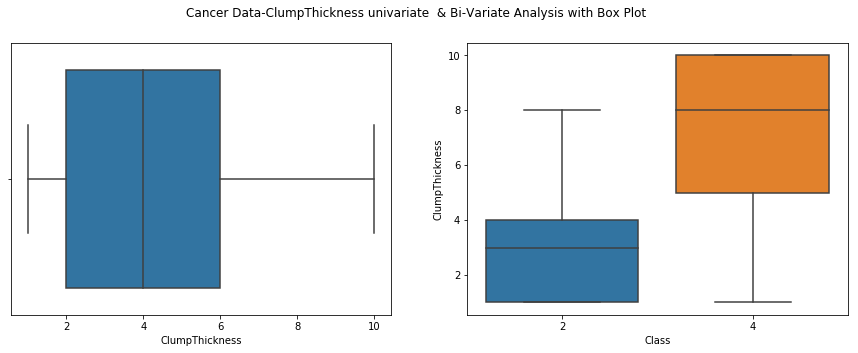

In [102]:
a4_dims = (15, 5)
fig, ax = plt.subplots(nrows=1, ncols=2,figsize=a4_dims)
fig.subplots_adjust(hspace=0.5)
fig.suptitle('Cancer Data-ClumpThickness univariate  & Bi-Variate Analysis with Box Plot')

sns.boxplot(data=cancer_df, x="ClumpThickness",ax=ax[0]);
sns.boxplot(data=cancer_df, y="ClumpThickness",x="Class",ax=ax[1]);



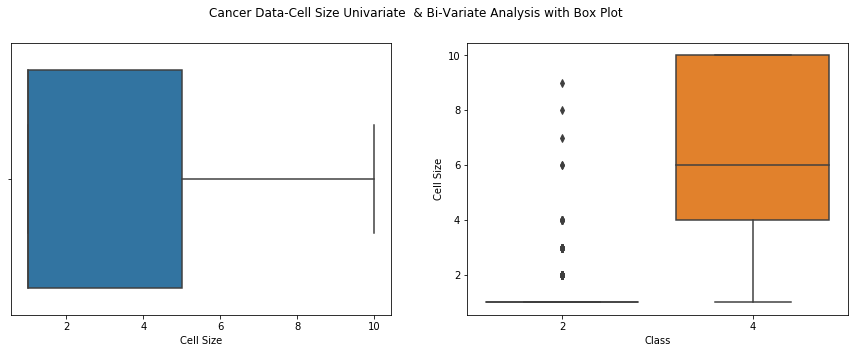

In [104]:
a4_dims = (15, 5)
fig, ax = plt.subplots(nrows=1, ncols=2,figsize=a4_dims)
fig.subplots_adjust(hspace=0.5)
fig.suptitle('Cancer Data-Cell Size Univariate  & Bi-Variate Analysis with Box Plot')

sns.boxplot(data=cancer_df, x="Cell Size",ax=ax[0]);
sns.boxplot(data=cancer_df, y="Cell Size",x="Class",ax=ax[1]);

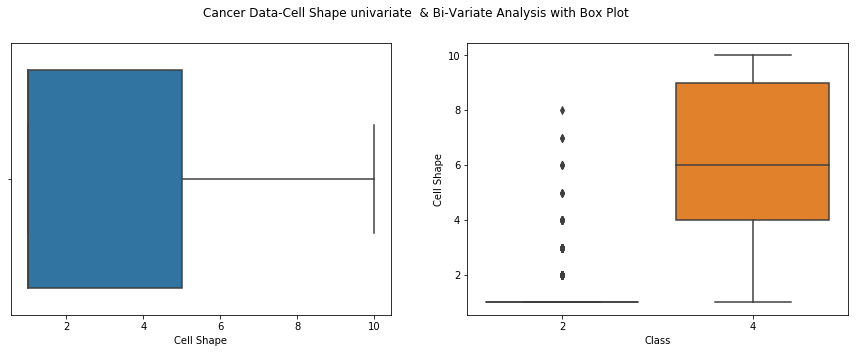

In [105]:
a4_dims = (15, 5)
fig, ax = plt.subplots(nrows=1, ncols=2,figsize=a4_dims)
fig.subplots_adjust(hspace=0.5)
fig.suptitle('Cancer Data-Cell Shape univariate  & Bi-Variate Analysis with Box Plot')

sns.boxplot(data=cancer_df, x="Cell Shape",ax=ax[0]);
sns.boxplot(data=cancer_df, y="Cell Shape",x="Class",ax=ax[1]);

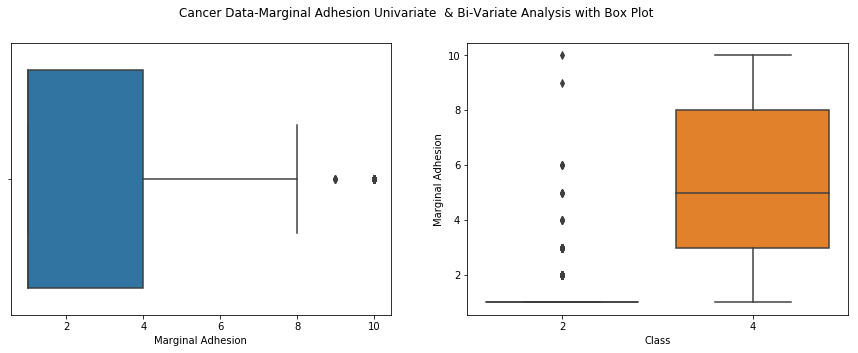

In [107]:
a4_dims = (15, 5)
fig, ax = plt.subplots(nrows=1, ncols=2,figsize=a4_dims)
fig.subplots_adjust(hspace=0.5)
fig.suptitle('Cancer Data-Marginal Adhesion Univariate  & Bi-Variate Analysis with Box Plot')

sns.boxplot(data=cancer_df, x="Marginal Adhesion",ax=ax[0]);
sns.boxplot(data=cancer_df, y="Marginal Adhesion",x="Class",ax=ax[1]);

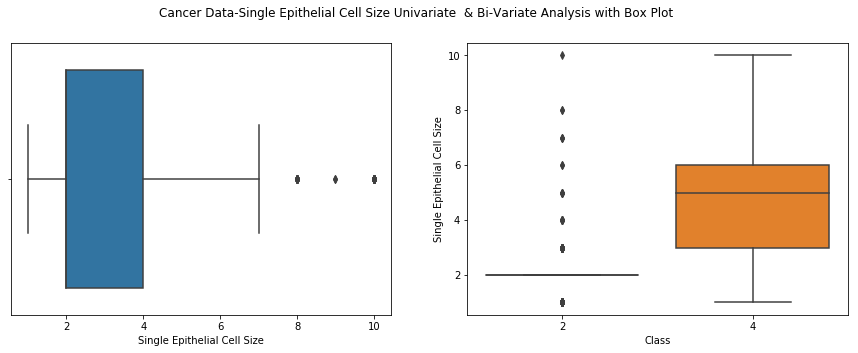

In [108]:
a4_dims = (15, 5)
fig, ax = plt.subplots(nrows=1, ncols=2,figsize=a4_dims)
fig.subplots_adjust(hspace=0.5)
fig.suptitle('Cancer Data-Single Epithelial Cell Size Univariate  & Bi-Variate Analysis with Box Plot')

sns.boxplot(data=cancer_df, x="Single Epithelial Cell Size",ax=ax[0]);
sns.boxplot(data=cancer_df, y="Single Epithelial Cell Size",x="Class",ax=ax[1]);

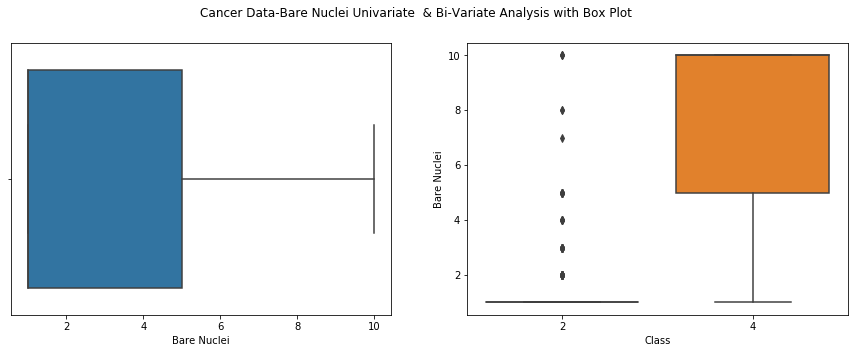

In [109]:
a4_dims = (15, 5)
fig, ax = plt.subplots(nrows=1, ncols=2,figsize=a4_dims)
fig.subplots_adjust(hspace=0.5)
fig.suptitle('Cancer Data-Bare Nuclei Univariate  & Bi-Variate Analysis with Box Plot')

sns.boxplot(data=cancer_df, x="Bare Nuclei",ax=ax[0]);
sns.boxplot(data=cancer_df, y="Bare Nuclei",x="Class",ax=ax[1]);

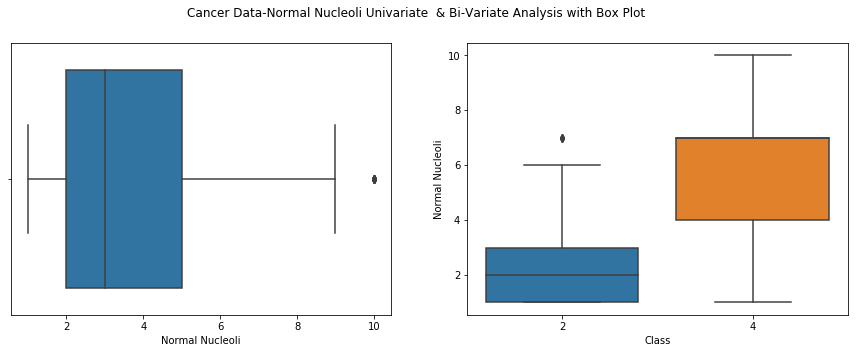

In [110]:
a4_dims = (15, 5)
fig, ax = plt.subplots(nrows=1, ncols=2,figsize=a4_dims)
fig.subplots_adjust(hspace=0.5)
fig.suptitle('Cancer Data-Normal Nucleoli Univariate  & Bi-Variate Analysis with Box Plot')

sns.boxplot(data=cancer_df, x="Normal Nucleoli",ax=ax[0]);
sns.boxplot(data=cancer_df, y="Normal Nucleoli",x="Class",ax=ax[1]);

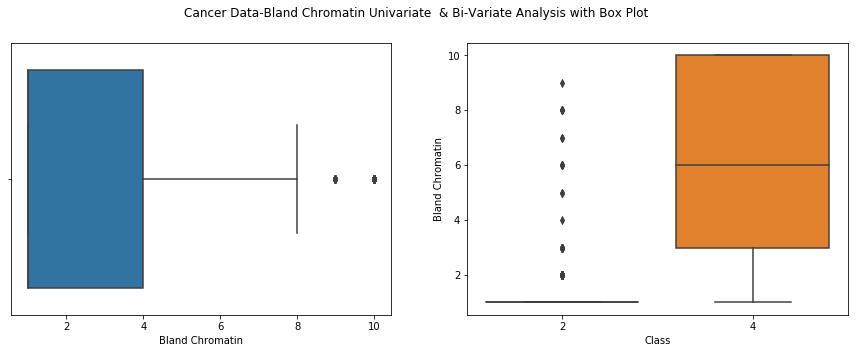

In [112]:
a4_dims = (15, 5)
fig, ax = plt.subplots(nrows=1, ncols=2,figsize=a4_dims)
fig.subplots_adjust(hspace=0.5)
fig.suptitle('Cancer Data-Bland Chromatin Univariate  & Bi-Variate Analysis with Box Plot')

sns.boxplot(data=cancer_df, x="Bland Chromatin",ax=ax[0]);
sns.boxplot(data=cancer_df, y="Bland Chromatin",x="Class",ax=ax[1]);

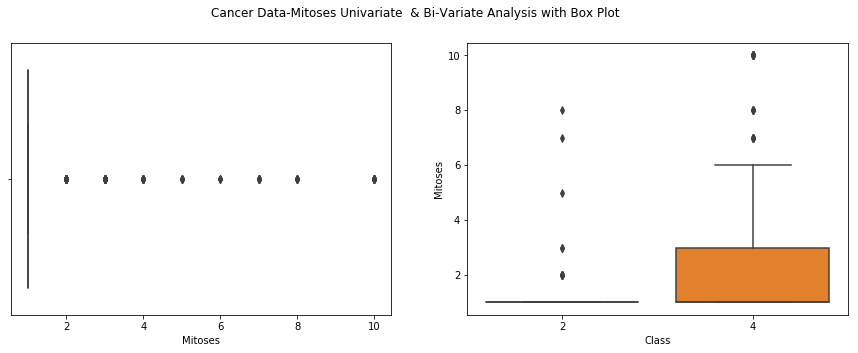

In [111]:
a4_dims = (15, 5)
fig, ax = plt.subplots(nrows=1, ncols=2,figsize=a4_dims)
fig.subplots_adjust(hspace=0.5)
fig.suptitle('Cancer Data-Mitoses Univariate  & Bi-Variate Analysis with Box Plot')

sns.boxplot(data=cancer_df, x="Mitoses",ax=ax[0]);
sns.boxplot(data=cancer_df, y="Mitoses",x="Class",ax=ax[1]);

In [ ]:
#Let us check for pair plots

C:\ProgramData\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval
C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\nonparametric\kde.py:488: RuntimeWarning: invalid value encountered in true_divide
  binned = fast_linbin(X, a, b, gridsize) / (delta * nobs)
C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\nonparametric\kdetools.py:34: RuntimeWarning: invalid value encountered in double_scalars
  FAC1 = 2*(np.pi*bw/RANGE)**2
C:\ProgramData\Anaconda3\lib\site-packages\numpy\core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


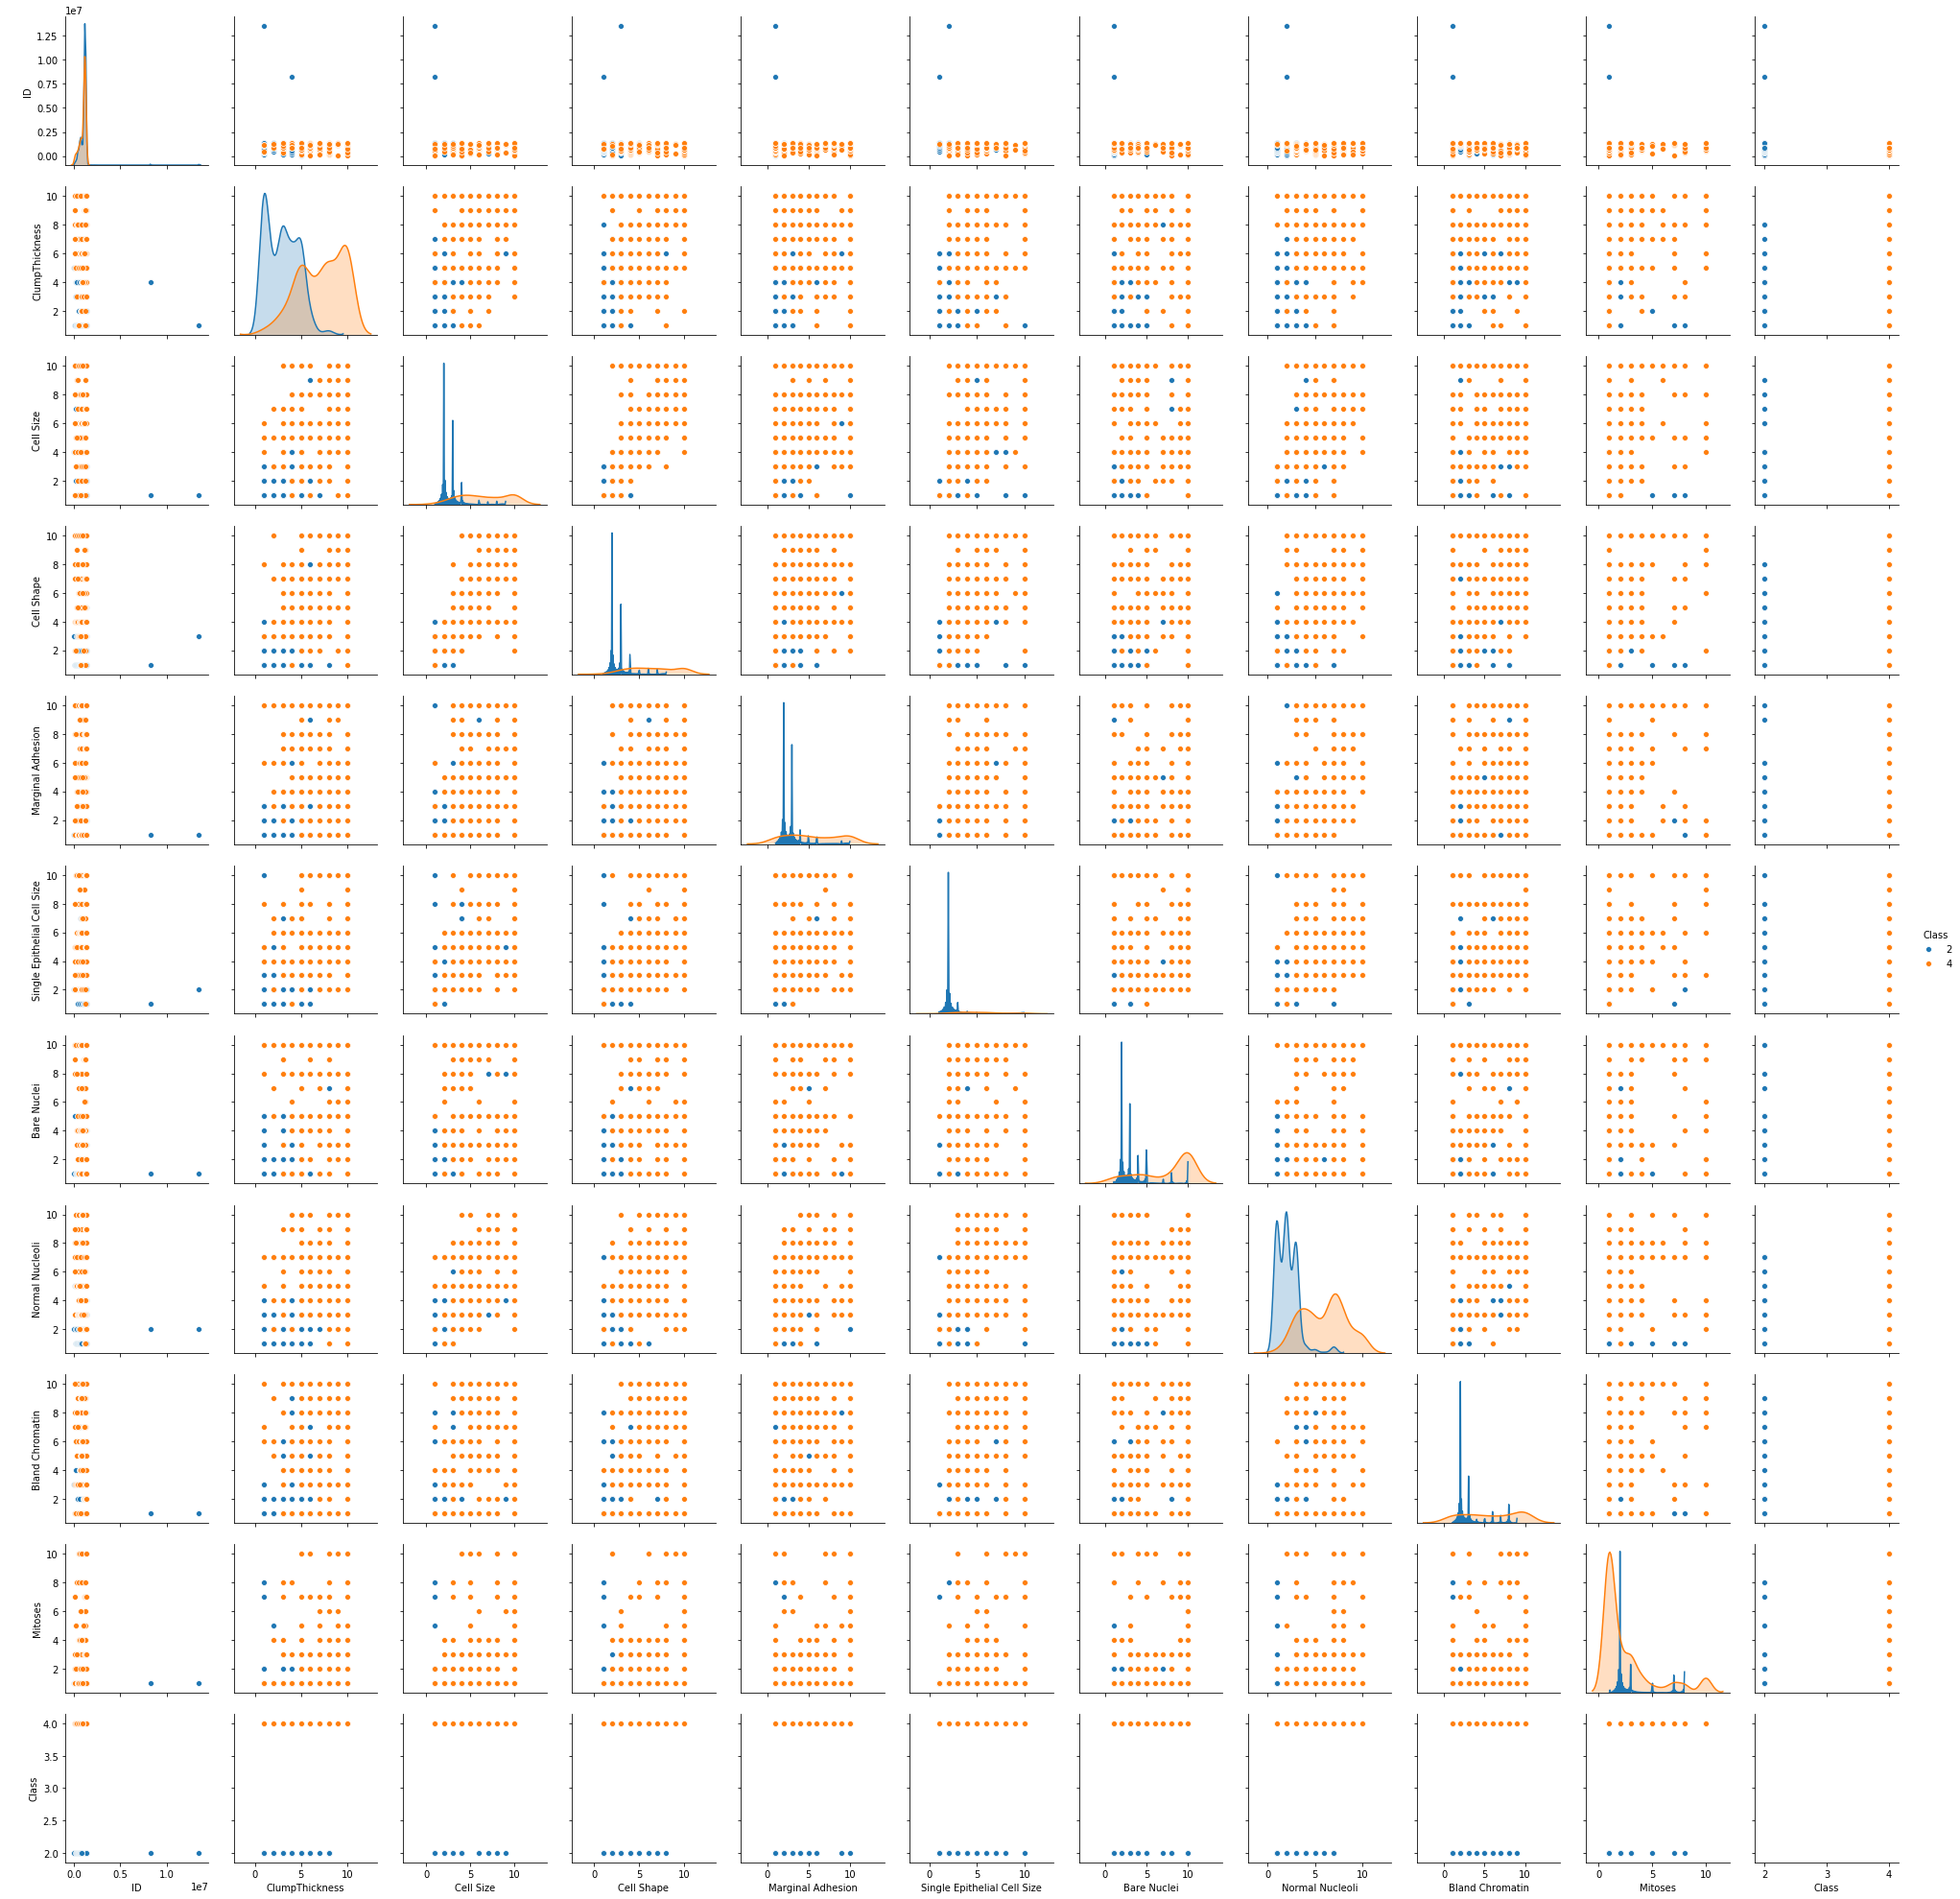

In [56]:
sns.pairplot(cancer_df, hue = 'Class')


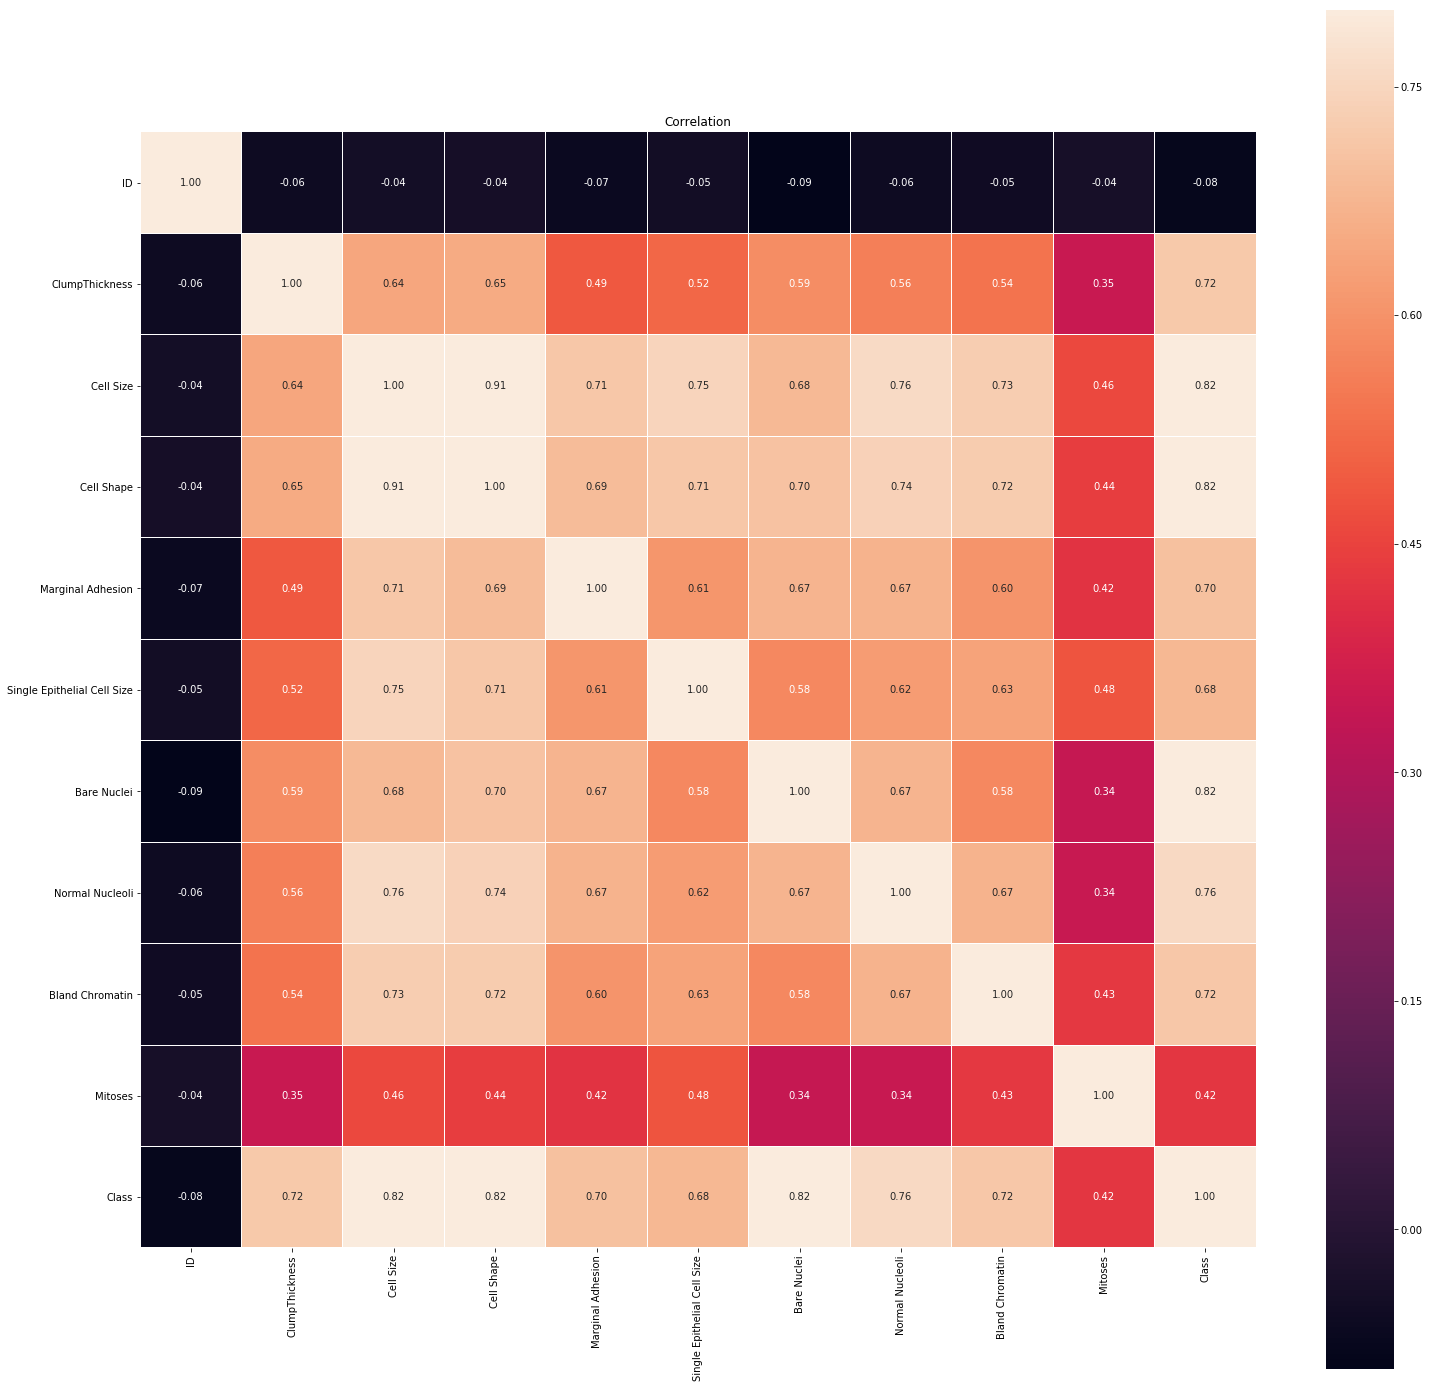

In [57]:
plt.figure(figsize=(25, 25))
ax = sns.heatmap(cancer_df.corr(), vmax=.8, square=True, fmt='.2f', annot=True, linecolor='white', linewidths=0.01)
plt.title('Correlation')
plt.show()

# Q5 Remove any unwanted columns or outliers, standardize variables in this pre-processing step

In [ ]:
# We could see most of the outliers are now removed.

In [58]:
#Drop 'ID', 'Class' features
X = cancer_df.drop(["ID","Class"], axis=1)
# Get Target variable in y
y = cancer_df["Class"]

In [59]:
#Standardize
# We transform (centralize) the entire X (independent variable data) to zscores through transformation. We will create the PCA dimensions
# on this distribution. 
sc = StandardScaler()
X_std =  sc.fit_transform(X)  
X_std

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\preprocessing\data.py:625: DataConversionWarning: Data with input dtype int64 were all converted to float64 by StandardScaler.
  return self.partial_fit(X, y)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\base.py:462: DataConversionWarning: Data with input dtype int64 were all converted to float64 by StandardScaler.
  return self.fit(X, **fit_params).transform(X)


array([[ 0.20282286, -0.70169775, -0.74503981, ..., -0.17861602,
        -0.61508162, -0.34486918],
       [ 0.20282286,  0.28506471,  0.26891969, ..., -0.17861602,
        -0.28886616, -0.34486918],
       [-0.50757194, -0.70169775, -0.74503981, ..., -0.17861602,
        -0.61508162, -0.34486918],
       ...,
       [ 0.20282286,  2.25858965,  2.2968387 , ...,  1.86864398,
         2.32085757,  0.23552042],
       [-0.15237454,  1.600748  ,  0.9448927 , ...,  2.68754798,
         1.0159957 , -0.34486918],
       [-0.15237454,  1.600748  ,  1.6208657 , ...,  2.68754798,
         0.36356477, -0.34486918]])

# Q6 Create a covariance matrix for identifying Principal components

In [60]:
# PCA
# Step 1 - Create covariance matrix
cov_matrix = np.cov(X_std.T)
print('Covariance Matrix \n%s', cov_matrix)

Covariance Matrix 
%s [[1.00145138 0.64410677 0.65453792 0.48842317 0.51800374 0.59150555
  0.56187702 0.53628373 0.35070402]
 [0.64410677 1.00145138 0.9066632  0.71396807 0.74806589 0.68556472
  0.76073447 0.7281282  0.46058509]
 [0.65453792 0.9066632  1.00145138 0.6917849  0.71527957 0.70518656
  0.73964761 0.72557104 0.44107467]
 [0.48842317 0.71396807 0.6917849  1.00145138 0.60916409 0.67348849
  0.67083263 0.60310209 0.41761286]
 [0.51800374 0.74806589 0.71527957 0.60916409 1.00145138 0.58132945
  0.62142658 0.63480034 0.48321685]
 [0.59150555 0.68556472 0.70518656 0.67348849 0.58132945 1.00145138
  0.67373075 0.57900023 0.34332099]
 [0.56187702 0.76073447 0.73964761 0.67083263 0.62142658 0.67373075
  1.00145138 0.67006996 0.34426827]
 [0.53628373 0.7281282  0.72557104 0.60310209 0.63480034 0.57900023
  0.67006996 1.00145138 0.42811085]
 [0.35070402 0.46058509 0.44107467 0.41761286 0.48321685 0.34332099
  0.34426827 0.42811085 1.00145138]]


# Q7 Identify eigen values and eigen vector

In [ ]:
# Step 2- Get eigen values and eigen vector

In [61]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print('Eigen Vectors \n%s', eigenvectors)
print('\n Eigen Values \n%s', eigenvalues)

Eigen Vectors 
%s [[-0.30202869  0.14902209 -0.86872874 -0.00254656 -0.02905197  0.26616691
  -0.19399832 -0.1501391  -0.00300703]
 [-0.38089144  0.04833557  0.03657788 -0.73669737  0.18962075 -0.43946502
  -0.23349186  0.09850317  0.12335951]
 [-0.37721125  0.08333455 -0.02039666  0.66430356  0.16770378 -0.58940349
  -0.15127833  0.06480163  0.08028927]
 [-0.33430954  0.05023423  0.39037637  0.04590901 -0.48684422  0.19404134
  -0.4924605  -0.46232255 -0.0168367 ]
 [-0.33589151 -0.17389022  0.15761632  0.06657451  0.32855055  0.38975065
   0.21090367 -0.06957883  0.72006348]
 [-0.33284901  0.24716817 -0.0294455  -0.07105867 -0.55680581 -0.15915546
   0.69544634  0.01237327  0.05514693]
 [-0.34648894  0.22989544  0.18320773  0.06252437  0.00966191  0.39882942
  -0.12659342  0.73810848 -0.26387659]
 [-0.3364694  -0.02071698  0.1357351  -0.02018486  0.47674458  0.1133626
   0.31256571 -0.41188028 -0.60004044]
 [-0.22972022 -0.90629849 -0.11603305  0.0080874  -0.22956737 -0.04272175
   0.

In [78]:
# Step 3 (continued): Sort eigenvalues in descending order

# Make a set of (eigenvalue, eigenvector) pairs
eig_pairs = [(eigenvalues[index], eigenvectors[:,index]) for index in range(len(eigenvalues))]

# Sort the (eigenvalue, eigenvector) pairs from highest to lowest with respect to eigenvalue
eig_pairs.sort()

eig_pairs.reverse()
print(eig_pairs)

# Extract the descending ordered eigenvalues and eigenvectors
eigvalues_sorted = [eig_pairs[index][0] for index in range(len(eigenvalues))]
eigvectors_sorted = [eig_pairs[index][1] for index in range(len(eigenvalues))]

# Let's confirm our sorting worked, print out eigenvalues
print('Eigenvalues in descending order: \n%s' %eigvalues_sorted)

[(5.908549765841713, array([-0.30202869, -0.38089144, -0.37721125, -0.33430954, -0.33589151,
       -0.33284901, -0.34648894, -0.3364694 , -0.22972022])), (0.7770568921769179, array([ 0.14902209,  0.04833557,  0.08333455,  0.05023423, -0.17389022,
        0.24716817,  0.22989544, -0.02071698, -0.90629849])), (0.540839598340637, array([-0.86872874,  0.03657788, -0.02039666,  0.39037637,  0.15761632,
       -0.0294455 ,  0.18320773,  0.1357351 , -0.11603305])), (0.46640500135359003, array([-0.02905197,  0.18962075,  0.16770378, -0.48684422,  0.32855055,
       -0.55680581,  0.00966191,  0.47674458, -0.22956737])), (0.3708354500653921, array([-0.00300703,  0.12335951,  0.08028927, -0.0168367 ,  0.72006348,
        0.05514693, -0.26387659, -0.60004044, -0.16380343])), (0.3018872495990659, array([-0.19399832, -0.23349186, -0.15127833, -0.4924605 ,  0.21090367,
        0.69544634, -0.12659342,  0.31256571,  0.0243831 ])), (0.29351972481620714, array([-0.1501391 ,  0.09850317,  0.06480163, -0

# Q8 Find variance and cumulative variance by each eigen vector

In [80]:
tot = sum(eigenvalues)
# an array of variance explained by each 
# eigen vector... there will be 9 entries as there are 9 eigen vectors)
var_explained = [(i / tot) for i in sorted(eigenvalues, reverse=True)] 
print("Variance Explained: \n", var_explained)
cum_var_exp = np.cumsum(var_explained)  # an array of cumulative variance. There will be 9 entries with 8 th entry 
# cumulative reaching almost 100%
print("Cumulative Variance: \n", cum_var_exp)

Variance Explained: 
 [0.6555540722487826, 0.08621452475199617, 0.06000619698175504, 0.05174767245291843, 0.04114422304268198, 0.033494414649558185, 0.03256603710118626, 0.029234955723370197, 0.010037903047751174]
Cumulative Variance: 
 [0.65555407 0.7417686  0.80177479 0.85352247 0.89466669 0.9281611
 0.96072714 0.9899621  1.        ]


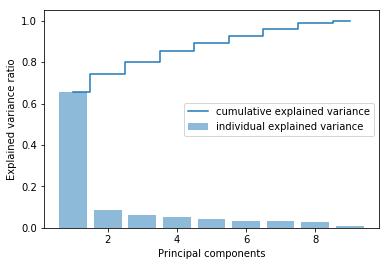

In [63]:
plt.bar(range(1,10), var_explained, alpha=0.5, align='center', label='individual explained variance')
plt.step(range(1,10),cum_var_exp, where= 'mid', label='cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.legend(loc = 'best')
plt.show()

# Q9 Use PCA command from sklearn and find Principal Components. Transform data to components formed

In [65]:
from sklearn.decomposition import PCA

In [81]:
#PCA components has been selected as 7 as per explained variance ratio which contain ~93% of variance
pca = PCA(n_components=7)
pca.fit(X_std)

PCA(copy=True, iterated_power='auto', n_components=7, random_state=None,
  svd_solver='auto', tol=0.0, whiten=False)

In [82]:
X_pca = pca.transform(X_std)

In [83]:
X_pca.shape

(690, 7)

In [84]:
#PCA Components
pca.components_

array([[ 0.30202869,  0.38089144,  0.37721125,  0.33430954,  0.33589151,
         0.33284901,  0.34648894,  0.3364694 ,  0.22972022],
       [-0.14902209, -0.04833557, -0.08333455, -0.05023423,  0.17389022,
        -0.24716817, -0.22989544,  0.02071698,  0.90629849],
       [-0.86872874,  0.03657788, -0.02039666,  0.39037637,  0.15761632,
        -0.0294455 ,  0.18320773,  0.1357351 , -0.11603305],
       [-0.02905197,  0.18962075,  0.16770378, -0.48684422,  0.32855055,
        -0.55680581,  0.00966191,  0.47674458, -0.22956737],
       [-0.00300703,  0.12335951,  0.08028927, -0.0168367 ,  0.72006348,
         0.05514693, -0.26387659, -0.60004044, -0.16380343],
       [ 0.19399832,  0.23349186,  0.15127833,  0.4924605 , -0.21090367,
        -0.69544634,  0.12659342, -0.31256571, -0.0243831 ],
       [-0.1501391 ,  0.09850317,  0.06480163, -0.46232255, -0.06957883,
         0.01237327,  0.73810848, -0.41188028,  0.1742704 ]])

In [85]:
pca.components_.shape

(7, 9)

In [86]:
pca.explained_variance_

array([5.90854977, 0.77705689, 0.5408396 , 0.466405  , 0.37083545,
       0.30188725, 0.29351972])

In [87]:
pca.explained_variance_ratio_

array([0.65555407, 0.08621452, 0.0600062 , 0.05174767, 0.04114422,
       0.03349441, 0.03256604])

# Q10 Find correlation between components and features

In [88]:
df = pd.DataFrame(X_pca)

C:\ProgramData\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval
C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\nonparametric\kde.py:488: RuntimeWarning: invalid value encountered in true_divide
  binned = fast_linbin(X, a, b, gridsize) / (delta * nobs)
C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\nonparametric\kdetools.py:34: RuntimeWarning: invalid value encountered in double_scalars
  FAC1 = 2*(np.pi*bw/RANGE)**2
C:\ProgramData\Anaconda3\lib\site-packages\numpy\core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


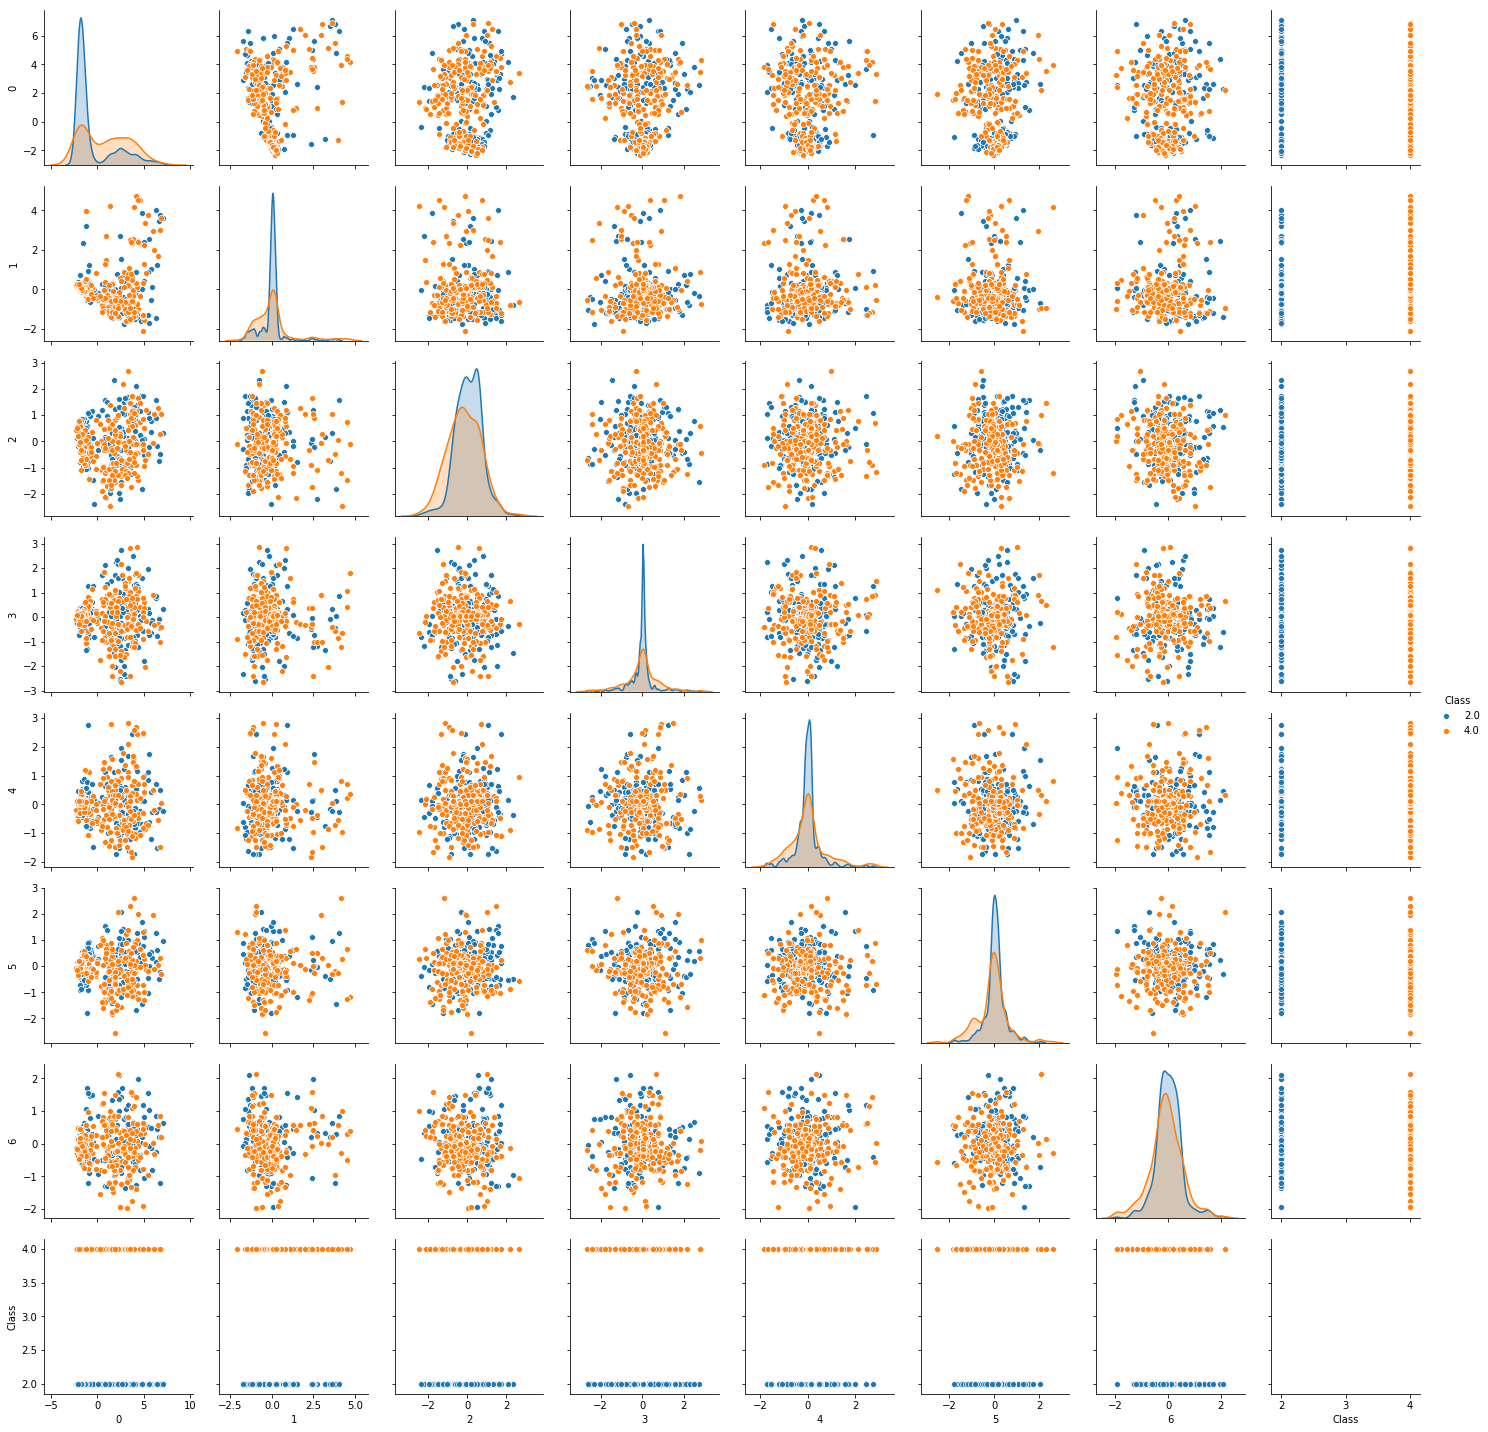

In [89]:
df = df.join(y)
#Pair plot with PCA data
sns.pairplot(df, diag_kind='kde',hue='Class') 

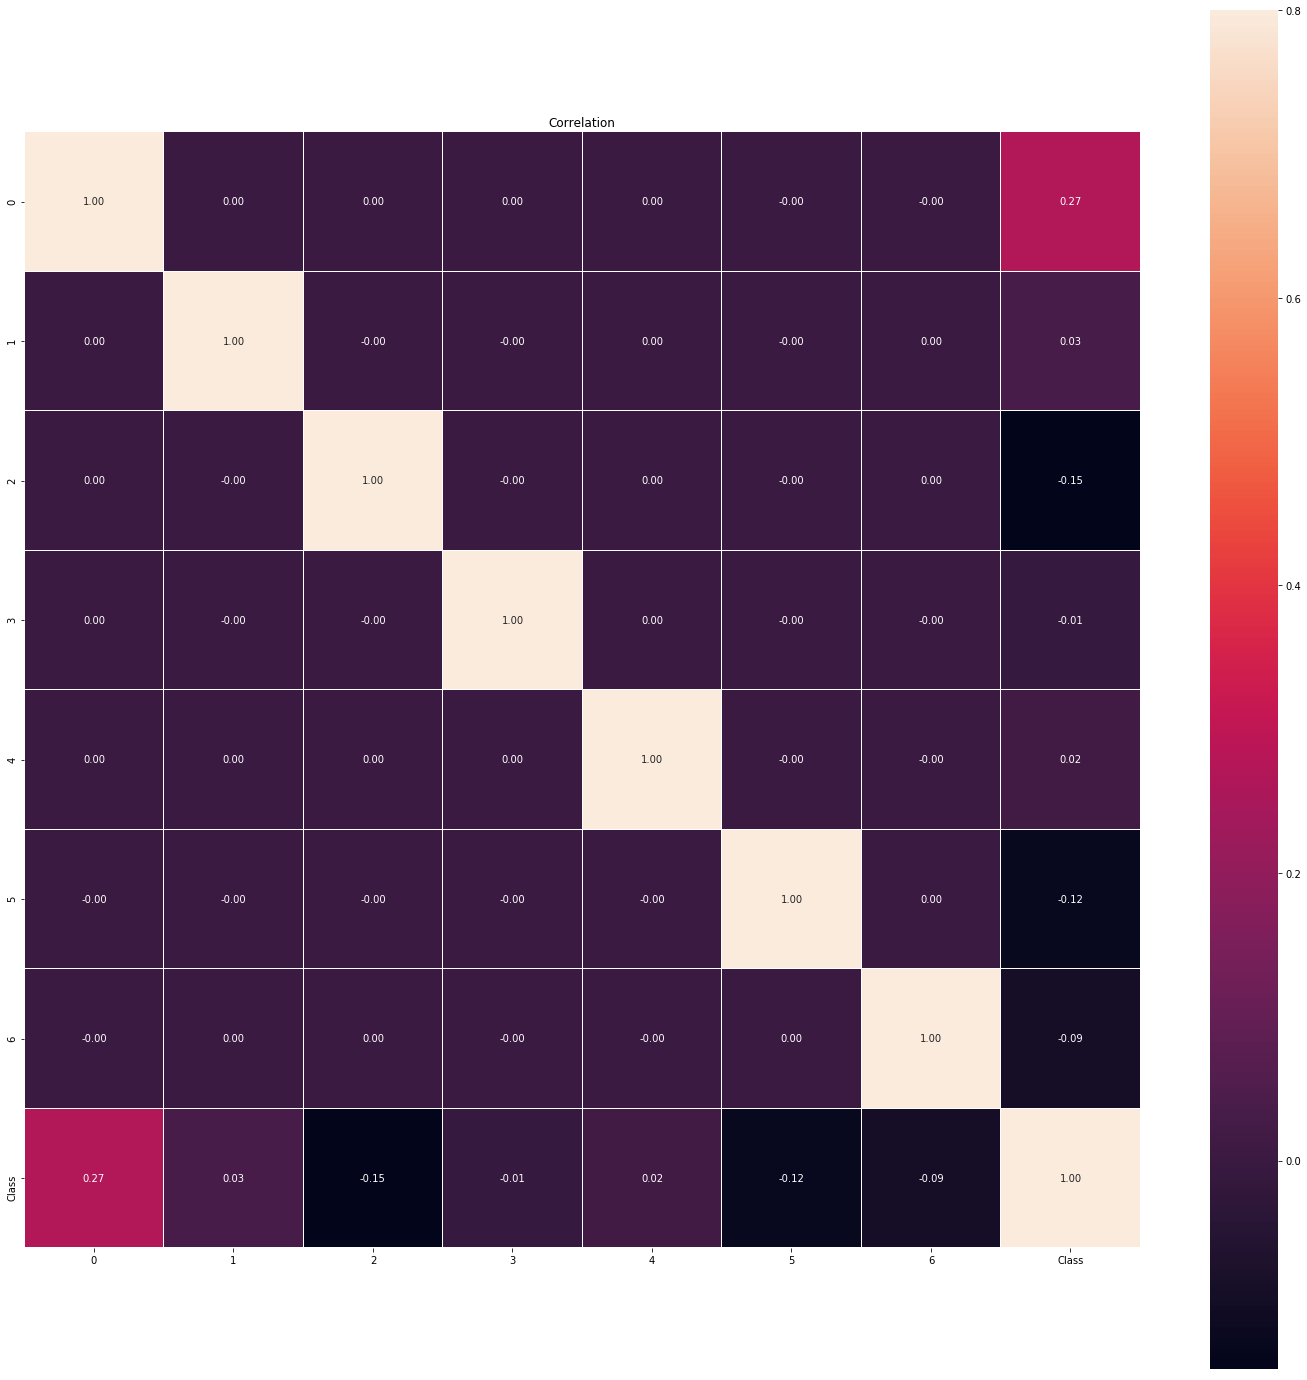

In [90]:
#Correlation Matrix After PCA
plt.figure(figsize=(25, 25))
ax = sns.heatmap(df.corr(), vmax=.8, square=True, fmt='.2f', annot=True, linecolor='white', linewidths=0.01)
plt.title('Correlation')
plt.show()